In [25]:
import os
from pathlib import Path

import ipynbname

primary_path = Path(ipynbname.path()).parent.parent.parent
print("Changing working directory to: ", primary_path)
os.chdir(primary_path)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors


plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "font.serif": ["Computer Modern Roman"],
})

Changing working directory to:  /Users/sylvia/dev/aeon


# Helper Functions

In [2]:
# Helper Functions
def load_evolve_data(path: str):
    dir = Path(f"output/{path}/")

    keys = []
    data = []

    for directory in dir.iterdir():
        if directory.is_dir():
            try:
                param = float(directory.name)
            except Exception as e:
               continue
            history_file = directory / "evolve_history.csv"

            if not history_file.is_file():
               continue

            keys.append(param)
            data.append(pd.read_csv(history_file))

    search = pd.read_csv(f"output/{path}/search/history.csv")

    return keys, data, search

# Plots

In [26]:
# Load Data
scalar_amplitudes, scalar_data, scalar_search = load_evolve_data("axicombo/0.0")
combo_amplitudes, combo_data, combo_search = load_evolve_data("axicombo/1.0")

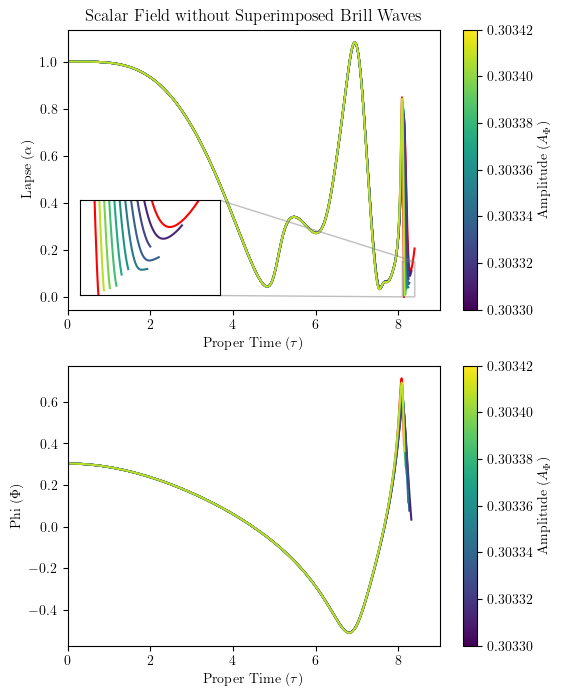

In [27]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

colormap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=0.3033, vmax=0.30342)

highlight_range = [0.3033, 0.30342]

inset_ax = axes[0].inset_axes((0.3, 0.01, 3.4, 0.4), transform=axes[0].transData)

for i in range(0, len(scalar_amplitudes)):
    # if not (scalar_amplitudes[i] in scalar_search["param"].to_list()):
    #     continue

    # if scalar_amplitudes[i] < 0.301:
    #     continue

    color = colormap(norm(scalar_amplitudes[i]))

    if not (scalar_amplitudes[i] in [0.303312, 0.30332400000000004, 0.303336, 0.303348, 0.30336, 0.30337200000000003, 0.303384, 0.303396, 0.303408] or scalar_amplitudes[i] in highlight_range):
        continue

    if scalar_amplitudes[i] in highlight_range:
        color = "red"

    # if highlight_range[0] <= scalar_amplitudes[i] and scalar_amplitudes[i] <= highlight_range[1]:
    #     color = 'red'

    # if scalar_amplitudes[i] < highlight_range[0] or scalar_amplitudes[i] > highlight_range[1]:
    #     continue

    axes[0].plot(scalar_data[i]["proper_time"], scalar_data[i]["alpha"], color=color)

    if "phi0" in scalar_data[i].columns:
        axes[1].plot(scalar_data[i]["proper_time"], scalar_data[i]["phi0"], color=color)
    inset_ax.plot(scalar_data[i]["proper_time"], scalar_data[i]["alpha"], color=color)


inset_ax.set_xlim(8.1, 8.4)
inset_ax.set_ylim(0.0, 0.15)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
axes[0].indicate_inset_zoom(inset_ax)

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(scalar_amplitudes)

cbar = fig.colorbar(sm, ax=axes[0], orientation="vertical")
cbar.set_label(r"Amplitude ($A_\Phi$)")
cbar = fig.colorbar(sm, ax=axes[1], orientation="vertical")
cbar.set_label(r"Amplitude ($A_\Phi$)")

axes[0].set_title("Scalar Field without Superimposed Brill Waves")
axes[0].set_xlim(0.0, 9.0)
axes[0].set_xlabel(r"Proper Time ($\tau$)")
axes[0].set_ylabel(r"Lapse ($\alpha$)")

# axes[1].set_xlim(7.0, 9.0)
axes[1].set_xlim(0.0, 9.0)
axes[1].set_xlabel(r"Proper Time ($\tau$)")
axes[1].set_ylabel(r"Phi ($\Phi$)")

fig.savefig("figures/scalar_field_without_brill_waves.pdf", bbox_inches='tight')

plt.show()

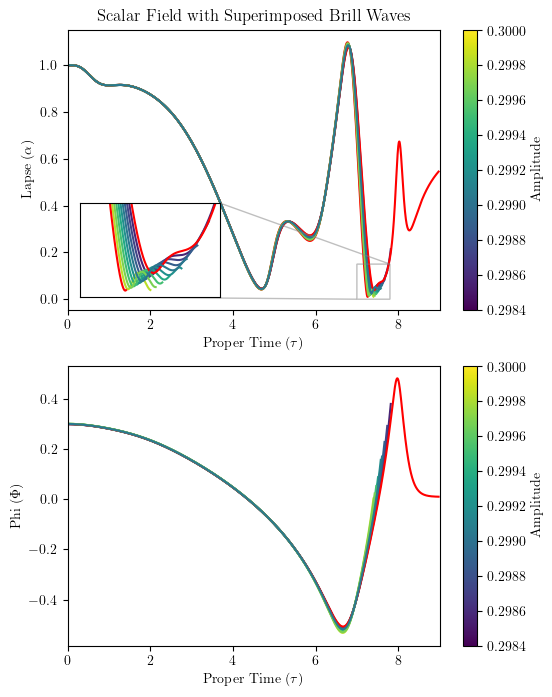

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(6, 8))

colormap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=0.2984, vmax=0.30000499999999997)

inset_ax = axes[0].inset_axes((0.3, 0.01, 3.4, 0.4), transform=axes[0].transData)

highlight_range = [0.2984, 0.30000499999999997]

# print(combo_search["param"].to_list())

for i in range(0, len(combo_amplitudes)):
    # if not (combo_amplitudes[i] in combo_search["param"].to_list()):
    #     continue

    # if combo_amplitudes[i] < .29 or combo_amplitudes[i] > 0.304:
    #     continue

    color = colormap(norm(combo_amplitudes[i]))

    # if highlight_range[0] <= combo_amplitudes[i] and combo_amplitudes[i] <= highlight_range[1]:
    #     color = 'red'

    # if combo_amplitudes[i] < highlight_range[0] or combo_amplitudes[i] > highlight_range[1]:
    #     continue

    if not (combo_amplitudes[i] in [0.29856000000000005, 0.29872, 0.29888, 0.29904, 0.2992, 0.29936, 0.29952, 0.29967999999999995, 0.29984] or combo_amplitudes[i] in highlight_range):
        continue

    if combo_amplitudes[i] in highlight_range:
        color = "red"

    axes[0].plot(combo_data[i]["proper_time"], combo_data[i]["alpha"], color=color)
    if "phi0" in combo_data[i].columns:
        axes[1].plot(combo_data[i]["proper_time"], combo_data[i]["phi0"], color=color)
    inset_ax.plot(combo_data[i]["proper_time"], combo_data[i]["alpha"], color=color)

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(combo_amplitudes)
cbar = fig.colorbar(sm, ax=axes[0], orientation="vertical")
cbar.set_label(r"Amplitude ($A_\Phi$)")

cbar = fig.colorbar(sm, ax=axes[1], orientation="vertical")
cbar.set_label(r"Amplitude ($A_\Phi$)")

inset_ax.set_xlim(7.0, 7.8)
inset_ax.set_ylim(0.0, 0.15)
inset_ax.set_xticks([])
inset_ax.set_yticks([])
axes[0].indicate_inset_zoom(inset_ax)

axes[0].set_title("Scalar Field with Superimposed Brill Waves")
axes[0].set_xlim(0.0, 9.0)
axes[0].set_xlabel(r"Proper Time ($\tau$)")
axes[0].set_ylabel(r"Lapse ($\alpha$)")

axes[1].set_xlim(0.0, 9.0)
axes[1].set_xlabel(r"Proper Time ($\tau$)")
axes[1].set_ylabel(r"Phi ($\Phi$)")

fig.savefig("figures/scalar_field_with_brill_waves.pdf", bbox_inches='tight')


plt.show()

Hi
Hi


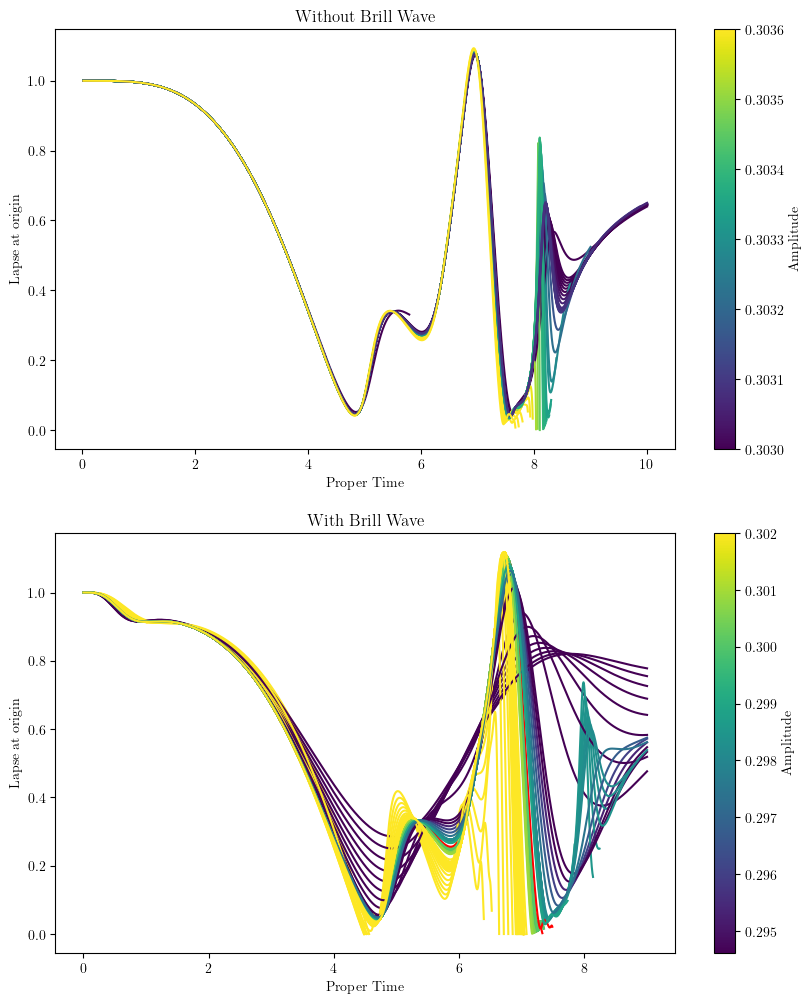

In [ ]:

fig, axes = plt.subplots(2, 1, figsize=(10, 12))

colormap = plt.get_cmap('viridis')
norm = mcolors.Normalize(vmin=0.303, vmax=0.3036)

for i in range(0, len(scalar_amplitudes)):
    color = colormap(norm(scalar_amplitudes[i]))
    # if highlight_range[0] <= scalar_amplitudes[i] and scalar_amplitudes[i] <= highlight_range[1]:
    #     color = "red"
    axes[0].plot(scalar_data[i]["proper_time"], scalar_data[i]["alpha"], color=color)
    # axes[0].plot(scalar_data[i]["proper_time"], scalar_data[i]["grr"] * scalar_data[i]["gzz"] - scalar_data[i]["grz"]**2, color=color)



sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(scalar_amplitudes)
cbar = fig.colorbar(sm, ax=axes[0], orientation="vertical")
cbar.set_label("Amplitude")

colormap = plt.get_cmap('viridis')
# norm = mcolors.Normalize(vmin=min(combo_amplitudes), vmax=max(combo_amplitudes))
norm = mcolors.Normalize(vmin=0.29461000, vmax=0.302)

for i in range(0, len(combo_amplitudes)):
    color = colormap(norm(combo_amplitudes[i]))

    # print("combo_amplitudes", combo_amplitudes[i])
    # print(combo_data[i]["proper_time"][len(combo_data[i]["proper_time"]) - 1])

    # if i != 4:
    #     continue

    if combo_amplitudes[i] == .30029000000000006 or combo_amplitudes[i] == .29958000000000007:
        # Maybe increase to .302?
        print("Hi")
        color = "red"        
    
    axes[1].plot(combo_data[i]["proper_time"], combo_data[i]["alpha"], color=color)
    # axes[1].plot(combo_data[i]["proper_time"], combo_data[i]["grr"] * combo_data[i]["gzz"] - combo_data[i]["grz"]**2, color=color)

sm = cm.ScalarMappable(cmap=colormap, norm=norm)
sm.set_array(combo_amplitudes)
cbar = fig.colorbar(sm, ax=axes[1], orientation="vertical")
cbar.set_label("Amplitude")

axes[0].set_title("Without Brill Wave")
axes[0].set_xlabel("Proper Time")
axes[0].set_ylabel("Lapse at origin")
# axes[0].set_xlim(7.9, 8.6)
# axes[0].set_ylim(0.58, 0.65)


axes[1].set_title("With Brill Wave")
axes[1].set_xlabel("Proper Time")
axes[1].set_ylabel("Lapse at origin")
# axes[1].set_xlim(6.5, 9.0)
# axes[1].set_xlim(6.38, 6.4)
# axes[1].set_ylim(0.0, 0.2)


plt.show()